# ATIVIDADE 1 - PRESSÃO VERSUS ELEVAÇÃO


## Grafico de Referência:

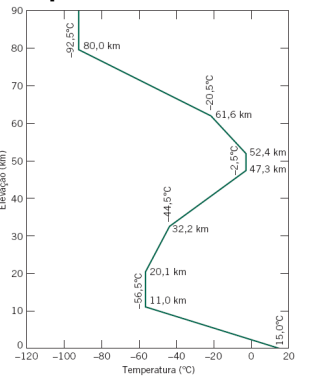

# Resoluções


## Parte 1


### **1) Para o intervalo de 11,0 até 20,1 km, onde a temperatura permanece constante (-56,5 C), obter um modelo que represente como a pressão varia com a elevação. Após obtenção da função p(E), sendo E a elevação, plotar o gráfico de Pressão X Elevação (pressão na ordenada);**

Para deduzir a função $p(E)$ em um intervalo com temperatura constante, usamos a **equação barométrica para uma atmosfera isotérmica**.

A partir da equação fundamental da estática dos fluidos:

$$dp = -\rho g dE \quad (1)$$

E da equação dos gases ideais:

$$p = \rho R T \implies \rho = \frac{p}{R T} \quad (2)$$

Substituindo (2) em (1):

$$dp = -\frac{p g}{R T} dE$$

Rearranjando para integrar:

$$\frac{dp}{p} = -\frac{g}{R T} dE$$

Integrando ambos os lados de uma elevação de referência $E_o$ (com pressão $p_o$) até uma elevação $E$ (com pressão $p$):

$$\int_{p_o}^{p} \frac{dp}{p} = -\frac{g}{R T} \int_{E_o}^{E} dE$$

$$\ln(p) - \ln(p_o) = -\frac{g}{R T} (E - E_o)$$

$$\ln\left(\frac{p}{p_o}\right) = -\frac{g}{R T} (E - E_o)$$

Para remover o logaritmo natural, exponenciamos ambos os lados:

$$\frac{p}{p_o} = e^{-\frac{g}{R T} (E - E_o)}$$

Finalmente, a função da pressão em relação à elevação para um intervalo isotérmico é:

$$p(E) = p_o e^{-\frac{g}{R T} (E - E_o)}$$

Onde:
*   $p(E)$ é a pressão na elevação $E$.
*   $p_o$ é a pressão na elevação de referência $E_o$.
*   $g = 9.81 \, \text{m/s}^2$ (aceleração gravitacional).
*   $R = 287 \, J/(s^2·K)$ (Constante específica dos gases para o ar atmosférico).
*   $T$ é a temperatura constante.
*   $E$ é a elevação.
*   $E_o$ é a elevação inicial.


#### Bibliotecas


In [368]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Definição das constantes

In [369]:
g = 9.81
R = 287.058
T_isotermico = -56.5
T_kelvin = T_isotermico + 273.15 # Convercao para Kelvin
p_0 = 101325

#### Cálculo da pressão para ${E_o}$ = 11 km, para ser utilizado como $p_o$.

Utilizando a formula encontrada na Parte 2 temos:

$$p(E) = p_o \cdot \left( \frac{T(E)}{(b)} \right)^{-\frac{g}{aR}}$$

In [370]:
a = -7.24810199
b = 293.22115289

def pressao_variavel(e):
    e_m = e*1000
    a_m = a/1000 # Pois ao ser feito a regressão linear usou-se km
    p = p_0*((a_m*e_m + b)/b)**(-(g/(a_m*R)))

    return p

p_11 = pressao_variavel(11)

print(f"Pressão em 11 km: {p_11} Pa")

Pressão em 11 km: 22695.26668918217 Pa


Para fins de comparação e maior veracidade, será utilizada a seguinte equação do livro Mecânica dos Fluidos de Frank M. White:

$$
P = P_0 \left( 1 - \frac{B z}{T_0} \right)^{\frac{g}{R B}}
$$

Onde:

$
\begin{aligned}
T_0 &= 288.16 \, \text{K} \quad \text{(temperatura ao nível do mar)} \\
B &= 0.0065 \, \text{K/m} \quad \text{(gradiente térmico)} \\
\end{aligned}
$

Aqui $T_0$ é a temperatura ao nível do mar (absoluta) e $B$ é a taxa de declínio, ambas
variando um pouco de um dia para outro. Por acordo internacional foram aceitos os
seguintes valores padrão a serem aplicados de 0 até 11.000 m:

In [371]:
B = 0.0065
t_0 = 288.16

def pressao_11(e):
    e = e * 1000
    p = p_0*(1-((B*e)/t_0))**((g/(R*B)))
    
    return p

p_11_padrao = pressao_11(11)

print(f"Pressão em 11 km: {p_11_padrao} Pa")

Pressão em 11 km: 22622.422542010907 Pa


#### Cálculo das pressões entre ${E_o}$ = 11 km e ${E}$ = 20,1 km:

In [372]:

def pressao_isotermica(e, e_0, p_inicial):
  e = e*1000
  e_0 = e_0*1000 # Conversao para m
  variacao = e - e_0

  p = p_inicial*(math.e**((-1*g/(R*T_kelvin))*variacao))

  return p

#### Plotagem do gráfico de Pressão X Elevação:


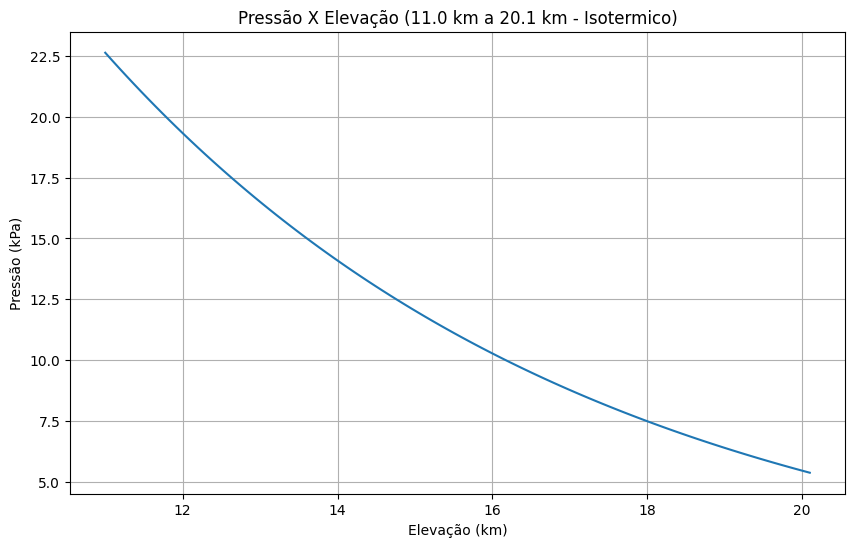

In [373]:
elevacoes = np.linspace(11.0, 20.1, 100)
e_0 = 11

pressao1 = pressao_isotermica(elevacoes, e_0, p_11_padrao)

plt.figure(figsize=(10, 6))
plt.plot(elevacoes, pressao1 / 1000) 
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (kPa)')
plt.title('Pressão X Elevação (11.0 km a 20.1 km - Isotermico)')
plt.grid(True)
plt.show()


## Parte 2



### **2) Para o intervalo de 0 até 11,0 km, onde a temperatura varia, utilizando os dados de temperatura em anexo, ajustar uma função T(E) utilizando o cálculo matricial do Método dos Mínimos Quadrados (MMQ, OLS em inglês). Após a obtenção da função de T(E), obter a função p(E), plotar o gráfico de Pressão X Elevação (pressão na ordenada).**


#### Abrir "Dados_Temperatura", e determinar dados



In [374]:
df = pd.read_excel("Dados_Temperatura.xlsx")

temperatura = df['Temperatura (K)']
altura = df['Elevação (km)']

print(df)

    Elevação (km)  Temperatura (K)
0               0       301.301604
1               1       278.240837
2               2       277.521503
3               3       260.259064
4               4       275.382433
5               5       252.070363
6               6       259.201939
7               7       248.331449
8               8       227.136951
9               9       226.493083
10             10       217.689877
11             11       216.650000


#### Método dos Mínimos Quadrados

$T(E) = aE + b$

E por meio do cálculos das matrizes:

$[Y] = [X] . [β]$

Onde:
*    $a$: Variação da temperatura
*    $b$: temperatura no nível do mar
*    $Y$: Matriz com valores da temperatura
*    $X$: Matriz com valores da elevação
*    $β$: Matriz com os coeficientes $a,b$ 

Resolvendo o sistema utilizando a *Matriz Pseudo-Inversa de Moore - Penrose* com o objetivo é encontrar $[β]$, fazendo $[β] = [X]^{-1} . [Y]$


In [375]:
Y = temperatura.to_numpy().reshape(-1,1)
X = altura.to_numpy().reshape(-1,1)
X = np.hstack((np.ones((Y.shape[0], 1)), X))

print('----- MATRIZ Y -----')
print(Y)
print()

print('----- MATRIZ X -----')
print(X)
print()

# Fazendo a pseudo-inversa de Moore_Penrose
X_pseudo = np.linalg.pinv(X)

# Para beta = [a, b]
beta = X_pseudo @ Y
b, a = beta

print('\nCoeficientes obtidos:')
print(f"a = {a}")
print(f"b = {b}")

----- MATRIZ Y -----
[[301.30160387]
 [278.24083745]
 [277.52150309]
 [260.25906395]
 [275.38243282]
 [252.07036337]
 [259.20193877]
 [248.33144933]
 [227.13695085]
 [226.49308318]
 [217.68987674]
 [216.65      ]]

----- MATRIZ X -----
[[ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]
 [ 1.  4.]
 [ 1.  5.]
 [ 1.  6.]
 [ 1.  7.]
 [ 1.  8.]
 [ 1.  9.]
 [ 1. 10.]
 [ 1. 11.]]


Coeficientes obtidos:
a = [-7.24810199]
b = [293.22115289]


#### Plotagem do grafico Temperatura X Elevação e sua Regressão Linear


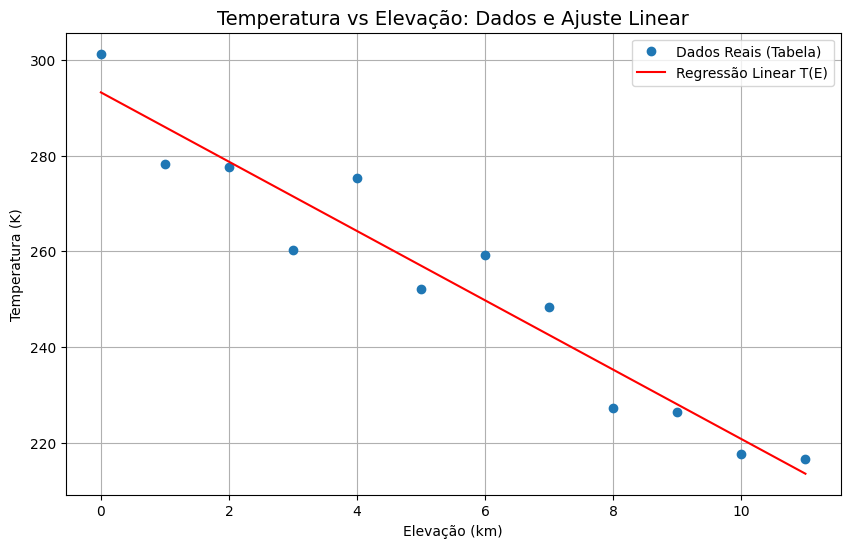

In [376]:
def t(e):
    return a*e + b

plt.figure(figsize=(10, 6))
plt.plot(altura, temperatura, 'o', label='Dados Reais (Tabela)')
plt.plot(altura, t(altura), 'r', label='Regressão Linear T(E)')
plt.title('Temperatura vs Elevação: Dados e Ajuste Linear', fontsize=14)
plt.xlabel('Elevação (km)')
plt.ylabel('Temperatura (K)')
plt.grid(True)
plt.legend()
plt.show()

$$ \frac{dp}{dz} = -ρg $$

Onde:

$$
\begin{aligned}
ρ = \frac{p}{R T}
\end{aligned}
$$

Então:

$$ \frac{dp}{dE} = \frac{-pg}{RT} $$
$$\int^{p}_{p_0} \frac{dP}{p} = -\frac{g}{R} \int^{E}_{E_0} \frac{dE}{T}$$
$$\int^{p}_{p_0} \frac{dP}{p}  = -\frac{g}{R} \int^{E}_{E_0} \frac{dE}{(aE+b)}$$

$$\frac{ln(p)}{ln(p_0)} = -\frac{g}{aR} \cdot \ln(\frac{aE+b}{b}) $$

$$ {ln(p)} = {ln(p_o)} \cdot -\frac{g}{aR}\cdot \ln(\frac{aE+b}{b}) $$

$$ {(e)} \cdot  {ln(p)} = {ln(p_o)} \cdot -\frac{g}{aR}\cdot \ln(\frac{aE+b}{b}) \cdot {(e)}$$

$$ {p} = {p_o} \cdot {(e)^{-\frac{g}{aR} \cdot \ln(\frac{aE+b}{b}) }}$$

$$
p = p_o \cdot e^{\left( \ln(\frac{aE+b}{b}) \right)^{-\frac{g}{aR}}} $$

$$
p = p_o \cdot \left( \frac{aE+b}{b} \right)^{-\frac{g}{aR}}$$

**Dessa maneira, podemos definir a função P(E) como:**

$$
p(E) = p_o \cdot \left( \frac{T(E)}{(b)} \right)^{-\frac{g}{aR}}$$

In [377]:
def pressao_variavel(e):
    T = t(e)
    e = e*(1000)
    a_m = a/(1000) # Pois ao ser feito a regressão linear usou-se km
    p = p_0*(T/b)**(-(g/(a_m*R)))

    return p

#### Plotagem do gráfico de Pressão X Elevação:


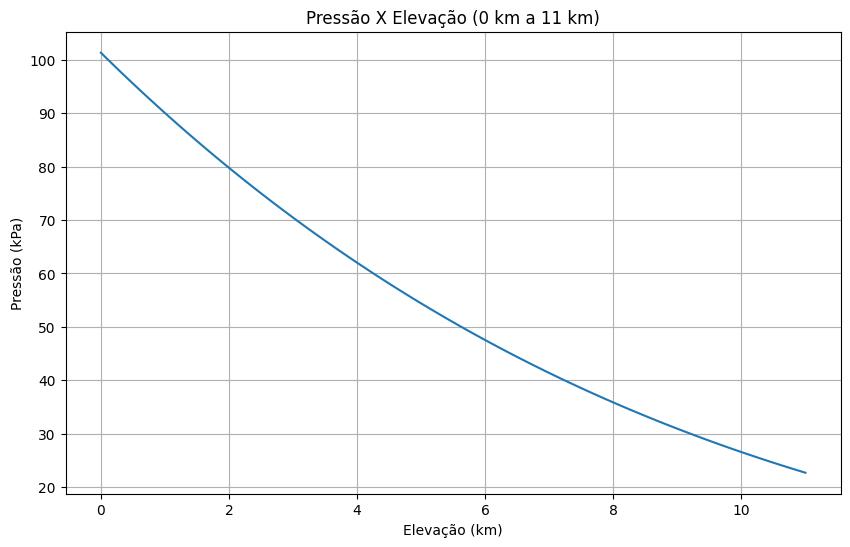

In [378]:
elevacao = np.linspace(0, 11, 100)

pressao2 = pressao_variavel(elevacao)

plt.figure(figsize=(10, 6))
plt.plot(elevacao, pressao2 / 1000)
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (kPa)')
plt.title('Pressão X Elevação (0 km a 11 km)')
plt.grid(True)
plt.show()


## Parte 3


### **3) Plotar o gráfico de Pressão X Elevação (pressão na ordenada) de 0 a 20,1 km.**

#### Grafico utilizando formula geral:


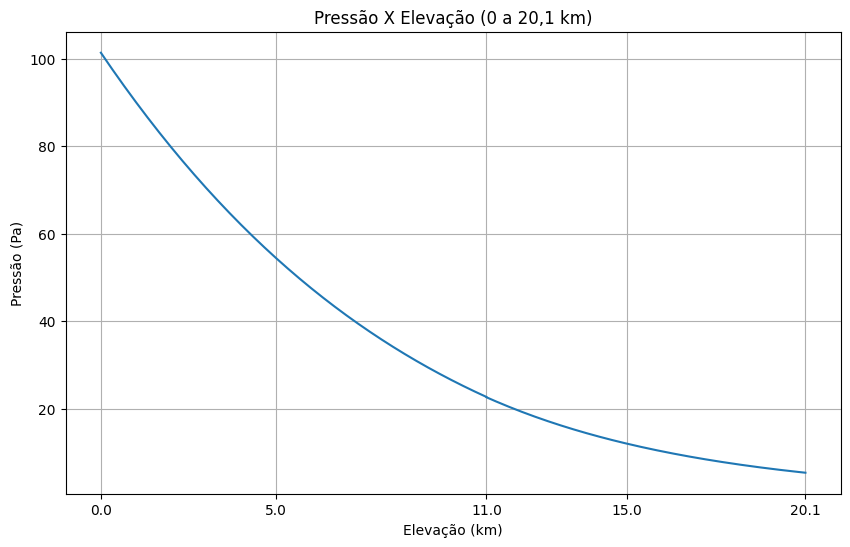

In [380]:

elevacao_geral = np.concatenate((elevacao, elevacoes))
pressao_geral = np.concatenate((pressao2, pressao1))

plt.figure(figsize=(10, 6))
plt.plot(elevacao_geral, pressao_geral / 1000)
plt.xlabel('Elevação (km)')
plt.ylabel('Pressão (Pa)')
plt.title('Pressão X Elevação (0 a 20,1 km)')
plt.xticks([0, 5, 11, 15, 20.1])
plt.grid(True)
plt.show()